# _**Plotting Magnetic Vector Field Data**_
===========================

This Notebook script contains code cells that plot time series of the vector magneticfield data from MagIE and the IAGA GIN for user defined input parameters. This script can download GIN one-minute (or one-second) data, and dowland MagIE one-second data. Basic data processing can be performed on the data and compare the time series as stacked plots.\
Author: Guanren Wang (gwang1@tcd.ie) Dec 2025 - May 2026.

In [1]:
import os
os.chdir("../src")
os.getcwd()

'/Users/guanrenwang/Desktop/MAGIE_works/MAGIE/src'

### Import standard python libraries and other conventional libraries

In [2]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

### Import functions from MagIE modules

In [3]:
from magie.Data_Download import get_GIN_data
from magie.Data_Download import download_magie
from magie.Data_Processing import one_minute_sampling
from magie.Data_Processing import fix_timestamp_duplicates
from magie.Data_Processing import fix_missing_timestamps
from magie.Data_Processing import means_calc
from magie.Data_Processing import compute_H
from magie.Data_Processing import calc_minute_derivatives
from magie.Plotting_Tools import plot_xyzf
from magie.Plotting_Tools import stack_plot

### Define input parameters
The IAGA Code is the official IAGA 3-letter station code. It should be in capital letters and correspond to the IAGA list of magnetic observatories.\
Data duration are in integer days. Orientation is best set to XYZF or DHZF. Note some observatories may not publish D and H-components.
Output file path can be set to a spceific output location for your figures. Example sets the output file path to the `Data` directory in the repository.

In [4]:
start_time = dt.datetime(2026, 1, 19, 11, 0, 0)
end_time = dt.datetime(2026, 1, 21, 23, 59, 59)
np_start_time = np.datetime64(start_time, 's')
np_end_time = np.datetime64(end_time, 's')
iagaSites = ["ESK", "HAD", "WNG", "NGK"]
dataDuration = 3
orientation = "XYZF"
output_file_path = Path(r'../Data/')

## Download GIN data in IAGA-2002 format then quick check to view GIN time series.
Optional argument `samples="Minute"`. Use `samples="Second"` if requiring one-second data. Set `state="best-avail"` for best avialable data. Or set `state="definitive"` for one-minute definitive data. There are no definitive one-second data.

3 day(s) of 2026-01-19 11:00:00 data for ESK 
        is getting extracted from:
https://imag-data.bgs.ac.uk/GIN_V1/GINServices?Request=GetData&observatoryIagaCode=ESK&samplesPerDay=Minute&dataStartDate=2026-01-19+11%3A00%3A00&dataDuration=3&publicationState=best-avail&Format=iaga2002&orientation=XYZF&%26recordTermination=UNIX
Mandatory file header records
0: [Format                 IAGA-2002]
1: [Source of Data         British Geological Survey (BGS)]
2: [Station Name           Eskdalemuir]
3: [IAGA Code              ESK]
4: [Geodetic Latitude      55.317]
5: [Geodetic Longitude     356.800]
6: [Elevation              245]
7: [Reported               XYZF]
8: [Sensor Orientation     HDZF]
9: [Digital Sampling       1-second]
10: [Data Interval Type     1-minute (00:30 - 01:30)]
11: [Data Type              quasi-definitive]
12: [Publication Date       2026-01-23]
13: [# Data file created on 20-01-2026 at 14:22:51]
14: [#]
15: [# This data file was created by the BGS geomagnetic data pro

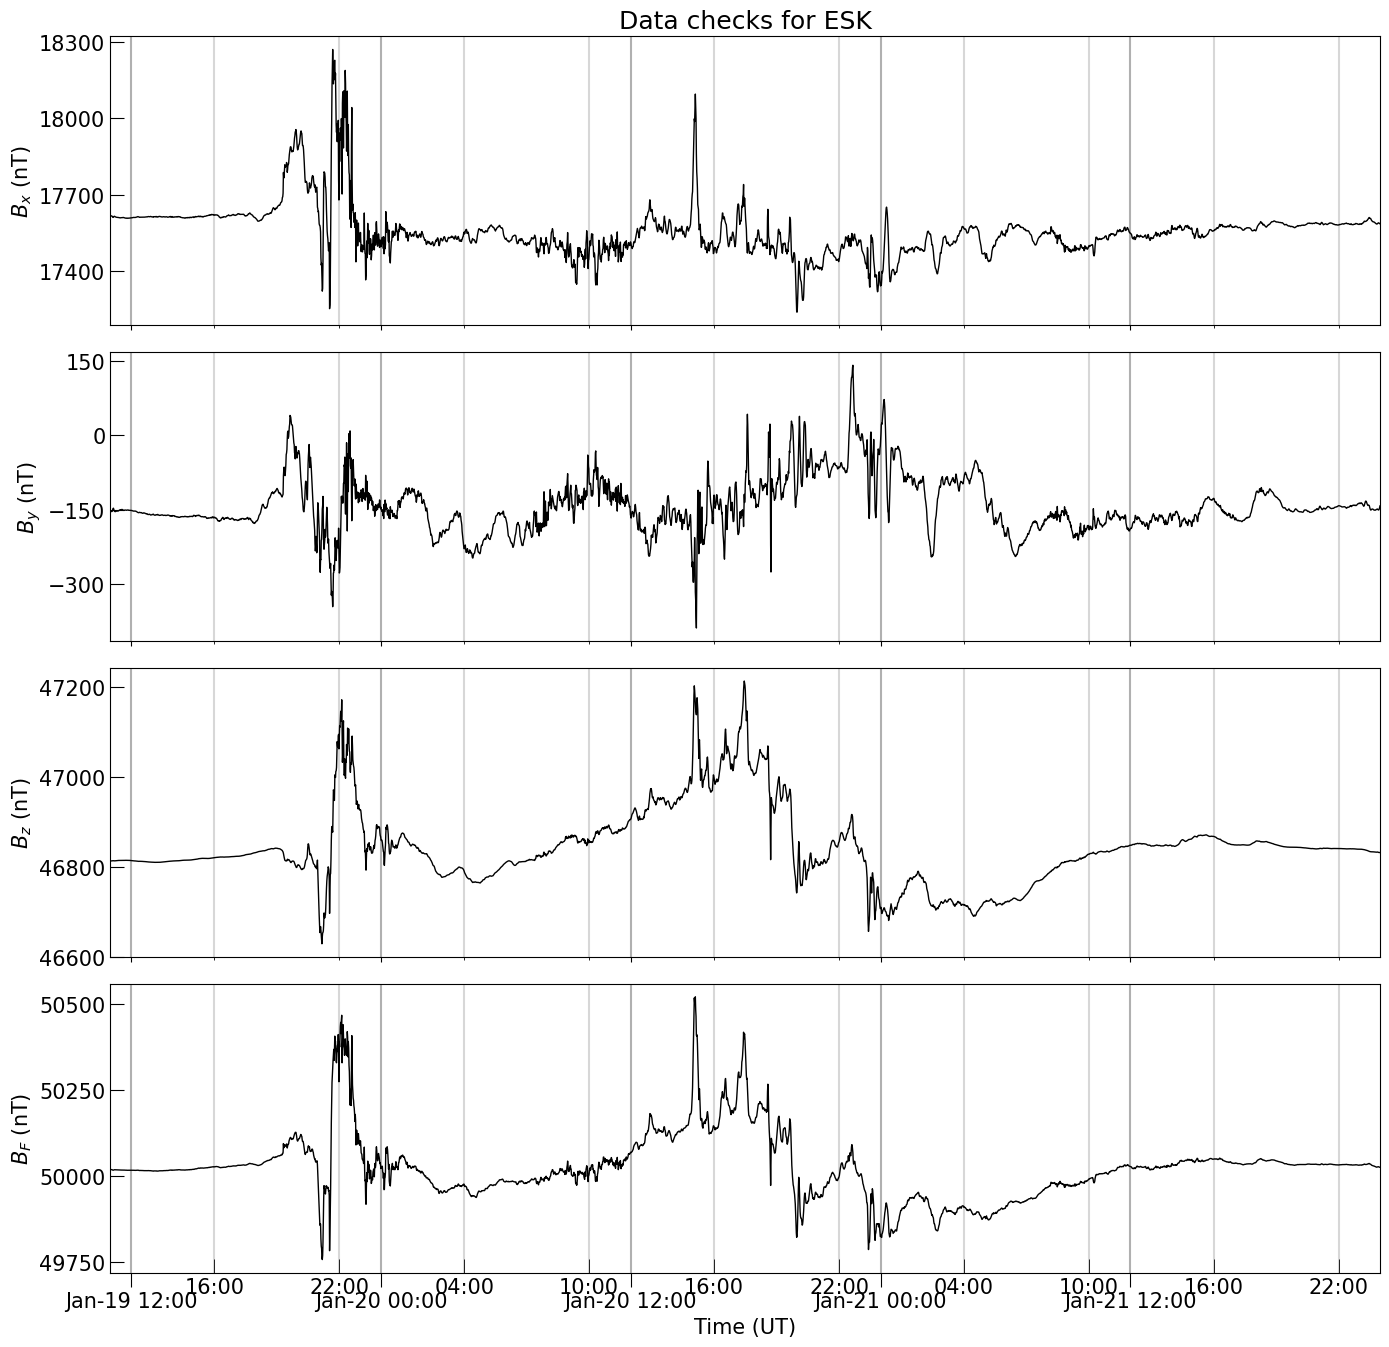

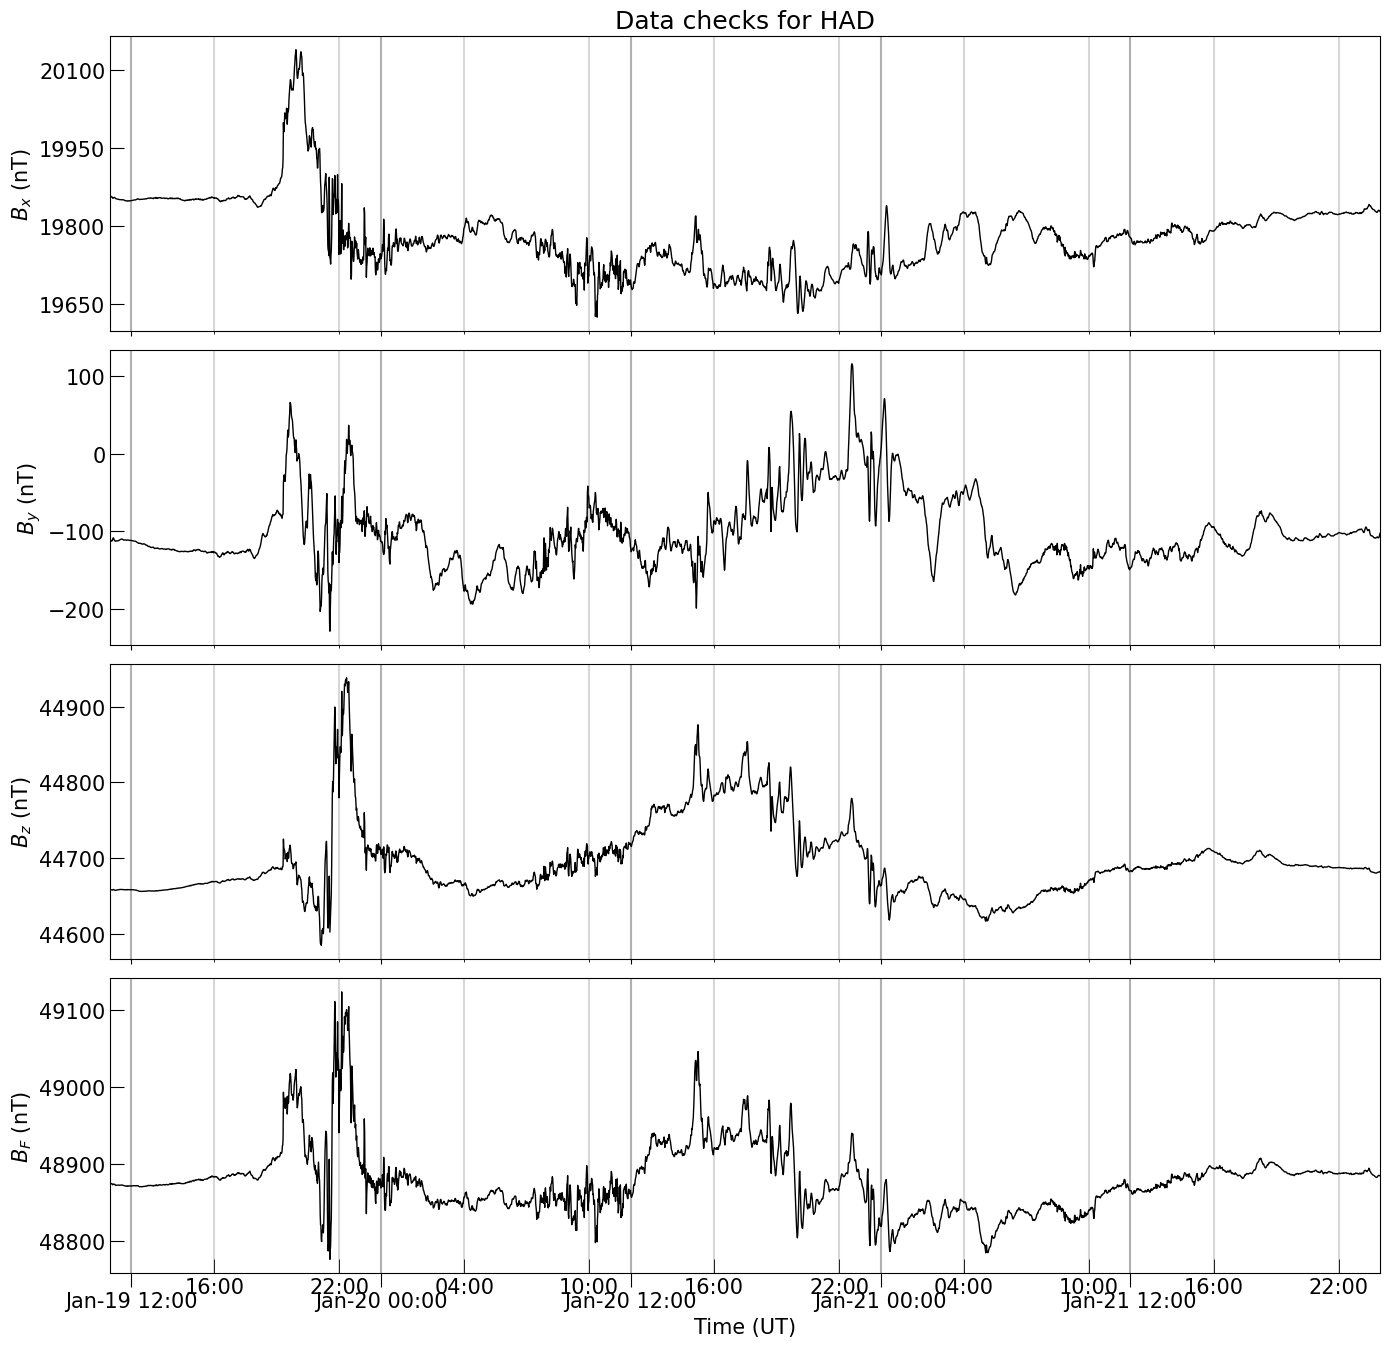

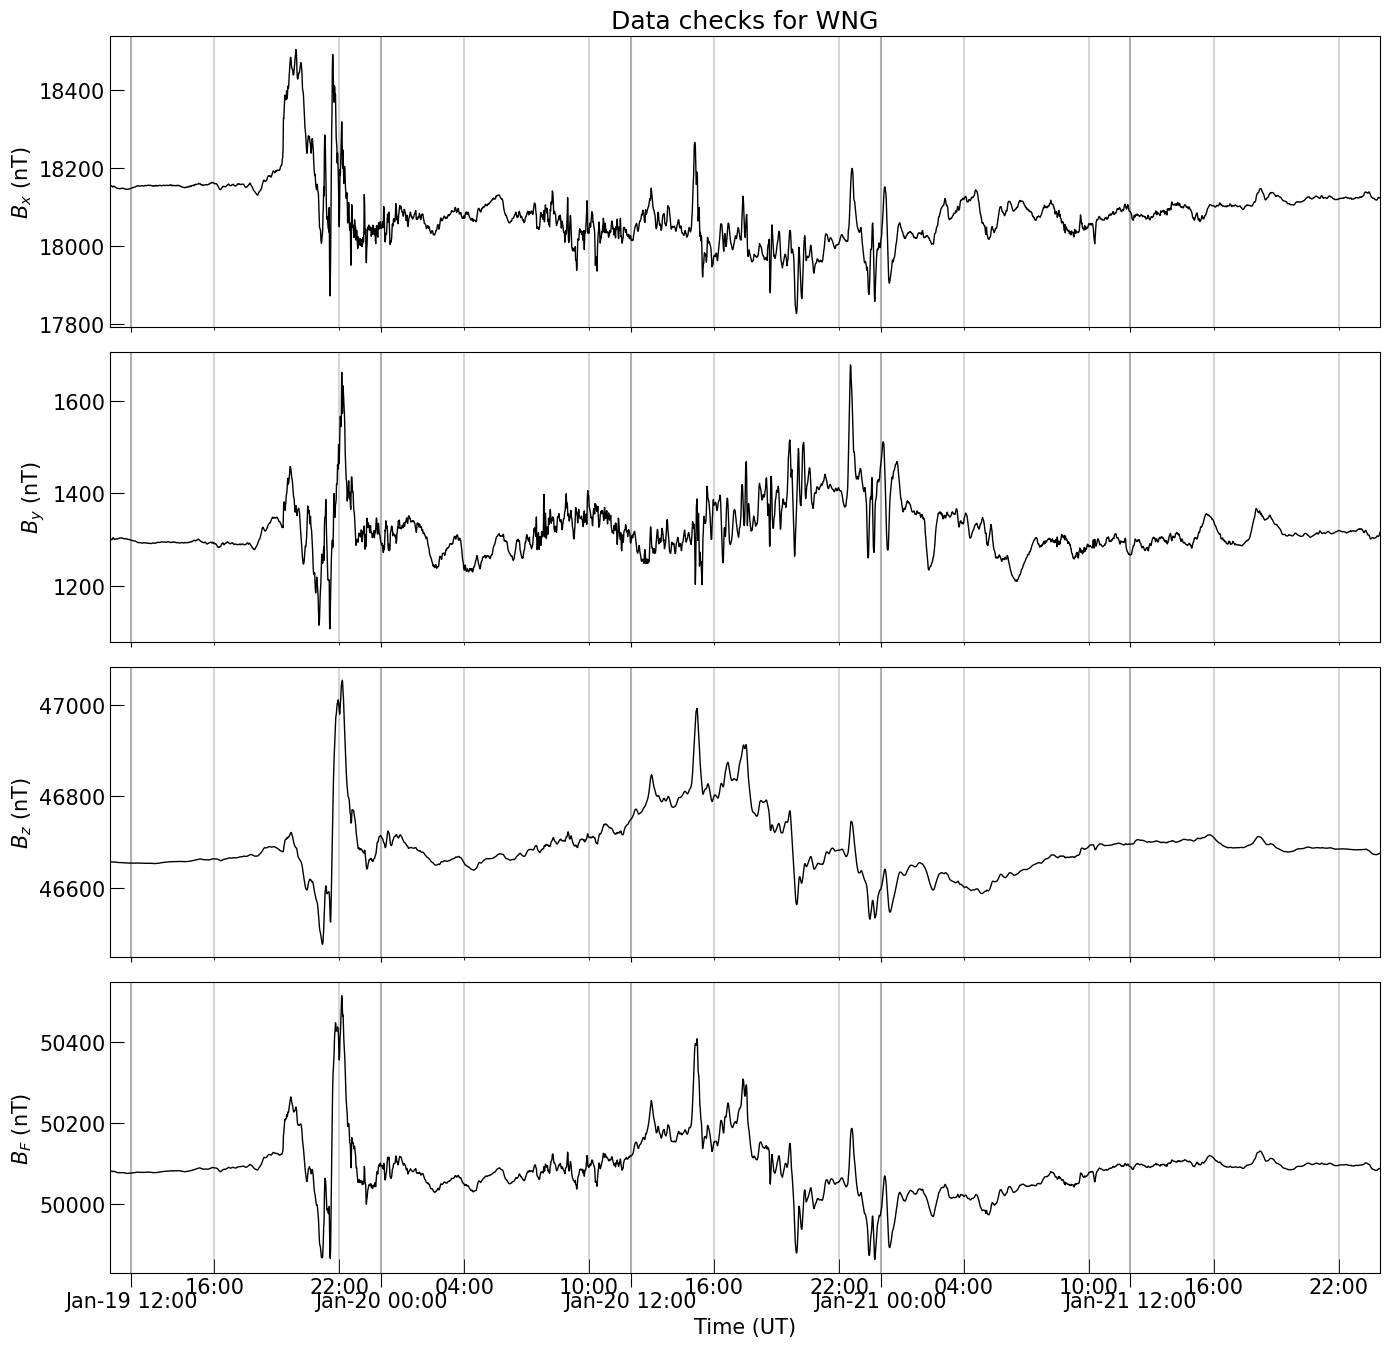

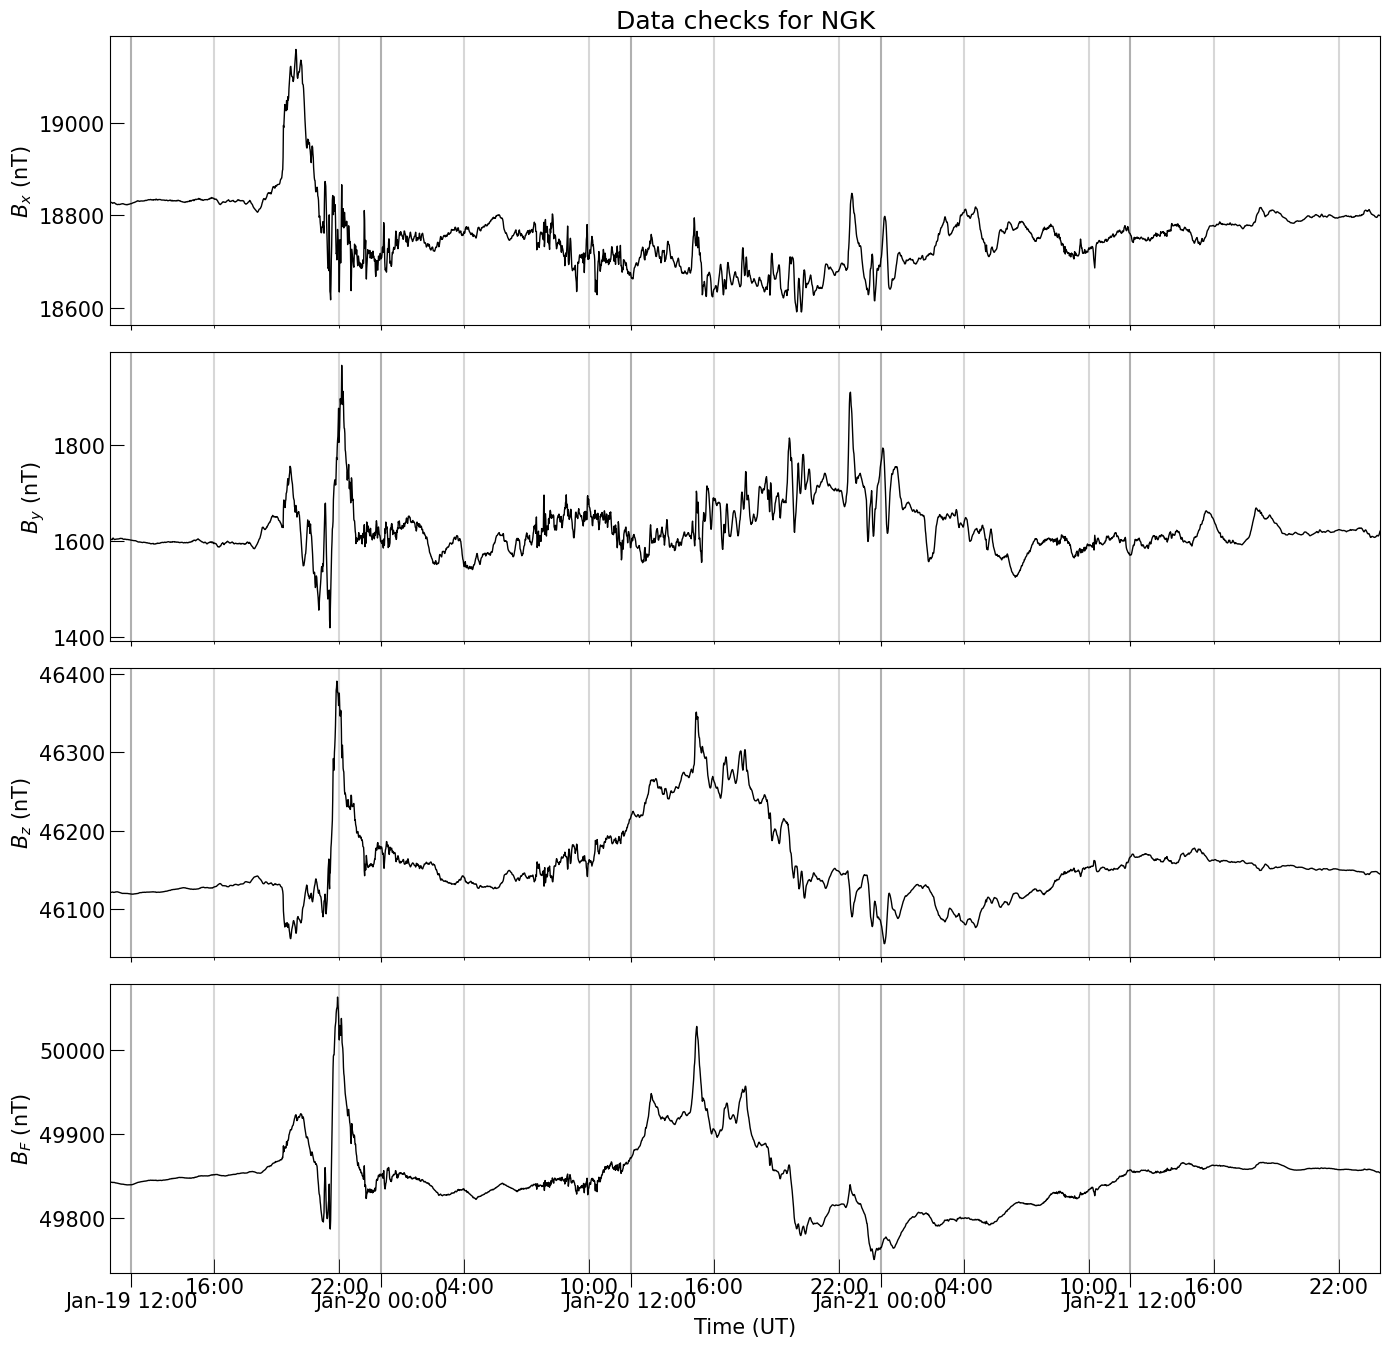

In [5]:
df_GIN = get_GIN_data(start_time, iagaSites, dataDuration, orientation)
for obs in iagaSites:
    title = f"Data checks for {obs}"
    fig, ax = plot_xyzf(df_GIN, obs, start_time, end_time, title, comps=["X", "Y", "Z", "F"])
    outfile = f"Check_{obs}_data.png"
    ff = Path(output_file_path, outfile)
    fig.savefig(ff, format="png")

### Download MagIE data as hdf5 file and perfom basic data processing.
Default file name generated instead of using save_file_name option is in the form of an hdf5 file e.g. `dun_val2025_11_11_to_2025_11_12.hdf5`. This script uses a user defined `file_name`.

In [6]:
hdf_file = f"MagIE_data_{np_start_time}_{np_end_time}.hdf5"
download_magie(np_start_time, np_end_time, sites=['dun', 'val'], save_file_name=hdf_file)

  0%|          | 0/3 [00:00<?, ?it/s]

Downloading: 100.00% [2457600/2450600 bytes]
Download complete!
Downloading: 100.00% [81920/73819 bytes]

 33%|███▎      | 1/3 [00:00<00:01,  1.03it/s]


Download complete!
Downloading: 100.00% [4268032/4259949 bytes]
Download complete!
Downloading: 100.00% [81920/73819 bytes]
Download complete!


 67%|██████▋   | 2/3 [00:03<00:01,  1.69s/it]

Downloading: 100.00% [2613248/2607601 bytes]
Download complete!
Downloading: 100.00% [81920/73819 bytes]

100%|██████████| 3/3 [00:04<00:00,  1.55s/it]


Download complete!


'MagIE_data_2026-01-19T11:00:00_2026-01-21T23:59:59.hdf5'

The HDF5 file <hdf_file> is moved to the destination directory. Example here moves the downloaded files to the MAGIE/Data/ directory in the repo.

In [7]:
notebook_dir = Path.cwd()
proj_dir = notebook_dir.parent
src_file = proj_dir / "src" / hdf_file
dst_dir = proj_dir / "Data"
if not src_file.exists():
    raise FileNotFoundError(f"Downloade MagIE file not found in {src_file}.")

dst_file = dst_dir / hdf_file
if dst_file.exists():
    print(f"File already exists, skipping {dst_file} ")
else:
    shutil.move(src_file, dst_dir)

At the moment the following cell block accounts for any duplicated timestamps or missing timestamps in the raw one-second magnetometer data at Dunsink collected using SENSYS magneometer, then saves the fixed timestamped data to `df_dun_duplicates_fixed`. Then one-second data are converted to one-minute data. There are occasional small data gaps at Dunsink before the LEMI installation so __one_minute_sample__ is used instead of a 61-point cosine filter that could produce a smoother result.

In [8]:
df = pd.read_hdf(Path(dst_dir, hdf_file), columns=['Date_UTC', 'Site', 'Bx', 'By', 'Bz'])

# Remove timezone after checking that it is UTC
df["Date_UTC"] = df["Date_UTC"].dt.tz_localize(None)

# assign individual dataframes for each site
df_dun = df[df['Site'].str.contains("dun")]
df_val = df[df['Site'].str.contains("val")]

# sort indexing in chronological order
df_dun = df_dun.set_index('Date_UTC')
df_val = df_val.set_index('Date_UTC')
df_val = df_val.sort_index()

# filter for start and end UTC times
df_dun = df_dun.loc[start_time:end_time]
df_val = df_val.loc[start_time:end_time]
df_GIN = df_GIN.loc[start_time:end_time]

# check for duplicates
dun_duplicates = df_dun.index[df_dun.index.duplicated()]

# fix duplicates
df_dun_duplicates_fixed = fix_timestamp_duplicates(df_dun)
df_dun_full = fix_missing_timestamps(df_dun_duplicates_fixed)

df_val = df_val.rename(columns={"Bx": "VALX", "By": "VALY", "Bz": "VALZ"})
df_dun_full = df_dun_full.rename(columns={"Bx": "DUNX",
                                            "By": "DUNY",
                                            "Bz": "DUNZ"})
df_val_minute = df_val.drop(columns=['Site'])

# run these lines if start_time and end_time don't end on full-minute
# Find the last full minute at Dunsink round down to nearest minute
last_minute = df_dun_full.index[-1].floor('min')
# Only keep rows with timestamp < next minute so it is divisible by 60 s
df_dun_full = df_dun_full[df_dun_full.index <= last_minute]

Bx_minute, Bx_resampled = one_minute_sampling(df_dun_full['DUNX'])
By_minute, Bz_resampled = one_minute_sampling(df_dun_full['DUNY'])
Bz_minute, Bz_resampled = one_minute_sampling(df_dun_full['DUNZ'])
timestamps_minute = Bx_minute.index

# Create a new DataFrame for one-minute Dunsink values
df_dun_minute = pd.DataFrame({
        'DUNX': Bx_minute,
        'DUNY': By_minute,
        'DUNZ': Bz_minute
        }, index=timestamps_minute)

print("HDF5 file ",
    "start time: ", df_dun_minute.index.min(),
    "end time: ", df_dun_minute.index.max()
    )

# put all the one minute files in the same dataframe
df_minute_obs = pd.concat([df_GIN, df_val_minute, df_dun_minute], axis=1)
df_minute_obs['DOY'] = df_minute_obs['DOY'].fillna(0).astype(int)

HDF5 file  start time:  2026-01-19 11:00:00 end time:  2026-01-21 13:58:00


In [9]:
df_dun_minute

,DUNX,DUNY,DUNZ
2026-01-19 11:00:00,18858.363500,923.527000,45371.566667
2026-01-19 11:01:00,18857.433167,923.268833,45371.824833
2026-01-19 11:02:00,18856.928167,923.115333,45371.778833
2026-01-19 11:03:00,18856.415000,923.272667,45371.722333
2026-01-19 11:04:00,18856.197000,923.648333,45371.326833
...,...,...,...
2026-01-21 13:54:00,18799.338000,905.288000,45402.907833
2026-01-21 13:55:00,18796.525333,903.740167,45405.064500
2026-01-21 13:56:00,18795.619000,898.971667,45406.261667
2026-01-21 13:57:00,18807.690500,897.781667,45404.042000


Concatenate all one-minute data together then compute H-component data from X and Y-components. Derive the one-minute derivative for each component. Group all components and their derivatives by observatory.

In [10]:
# find the mean values of all the observatory data that requires plotting
means = {}
# Decimal or integer hours to compute quiet-time mean before geomagnetic storm disturbance
hours = 5.0
obs_plot_list = ['esk', 'wng', 'dun', 'ngk', 'val', 'had']
for obs in obs_plot_list:
    ob = obs.upper()
    df_minute_obs = compute_H(df_minute_obs, ob)
    df_minute_obs = calc_minute_derivatives(df_minute_obs, ob)
    df_minute_obs = df_minute_obs.loc[:, ~df_minute_obs.columns.duplicated()]
    means[ob] = means_calc(df_minute_obs, ob, hours)

# Explicitly defined column order
components = ["X", "Y", "Z", "H", "dXdt", "dYdt", "dZdt", "dHdt"]
ordered_cols = []
# sort columns so that same observatory columns stay grouped
for obs in obs_plot_list:
    ob = obs.upper()
    for comp in components:
        col=f"{ob}{comp}"
        if col in df_minute_obs:
            ordered_cols.append(col)

df_minute_obs = df_minute_obs[ordered_cols]

Check the list of columns in `df_minute_obs` for observatory data in `obs_plot_list`.

In [11]:
df_minute_obs.columns.to_list()

['ESKX',
 'ESKY',
 'ESKZ',
 'ESKH',
 'ESKdXdt',
 'ESKdYdt',
 'ESKdZdt',
 'ESKdHdt',
 'WNGX',
 'WNGY',
 'WNGZ',
 'WNGH',
 'WNGdXdt',
 'WNGdYdt',
 'WNGdZdt',
 'WNGdHdt',
 'DUNX',
 'DUNY',
 'DUNZ',
 'DUNH',
 'DUNdXdt',
 'DUNdYdt',
 'DUNdZdt',
 'DUNdHdt',
 'NGKX',
 'NGKY',
 'NGKZ',
 'NGKH',
 'NGKdXdt',
 'NGKdYdt',
 'NGKdZdt',
 'NGKdHdt',
 'VALX',
 'VALY',
 'VALZ',
 'VALH',
 'VALdXdt',
 'VALdYdt',
 'VALdZdt',
 'VALdHdt',
 'HADX',
 'HADY',
 'HADZ',
 'HADH',
 'HADdXdt',
 'HADdYdt',
 'HADdZdt',
 'HADdHdt']

### Stacked plots of the field variations from mutiple observatories in each component
Time series of best available data.

Using vertical spacing of 155 nT
ESK X mean is:  17613.674617940196 nT
WNG X mean is:  18154.7365448505 nT
DUN X mean is:  18854.67449795409 nT
NGK X mean is:  18831.233521594684 nT
VAL X mean is:  19509.947375415282 nT
HAD X mean is:  19852.073986710962 nT
ESK Y mean is:  -159.2668438538206 nT
WNG Y mean is:  1295.4285049833886 nT
DUN Y mean is:  917.7874378531071 nT
NGK Y mean is:  1598.7311295681063 nT
VAL Y mean is:  -1597.0873421926913 nT
HAD Y mean is:  -120.06431893687707 nT
ESK Z mean is:  46813.68272425249 nT
WNG Z mean is:  46656.39478405316 nT
DUN Z mean is:  45371.80905553991 nT
NGK Z mean is:  46123.51279069767 nT
VAL Z mean is:  44877.60873754153 nT
HAD Z mean is:  44660.51661129568 nT
Plot Mid-Latitude_Jan19-21_Bxyz.png is saved in ../Data


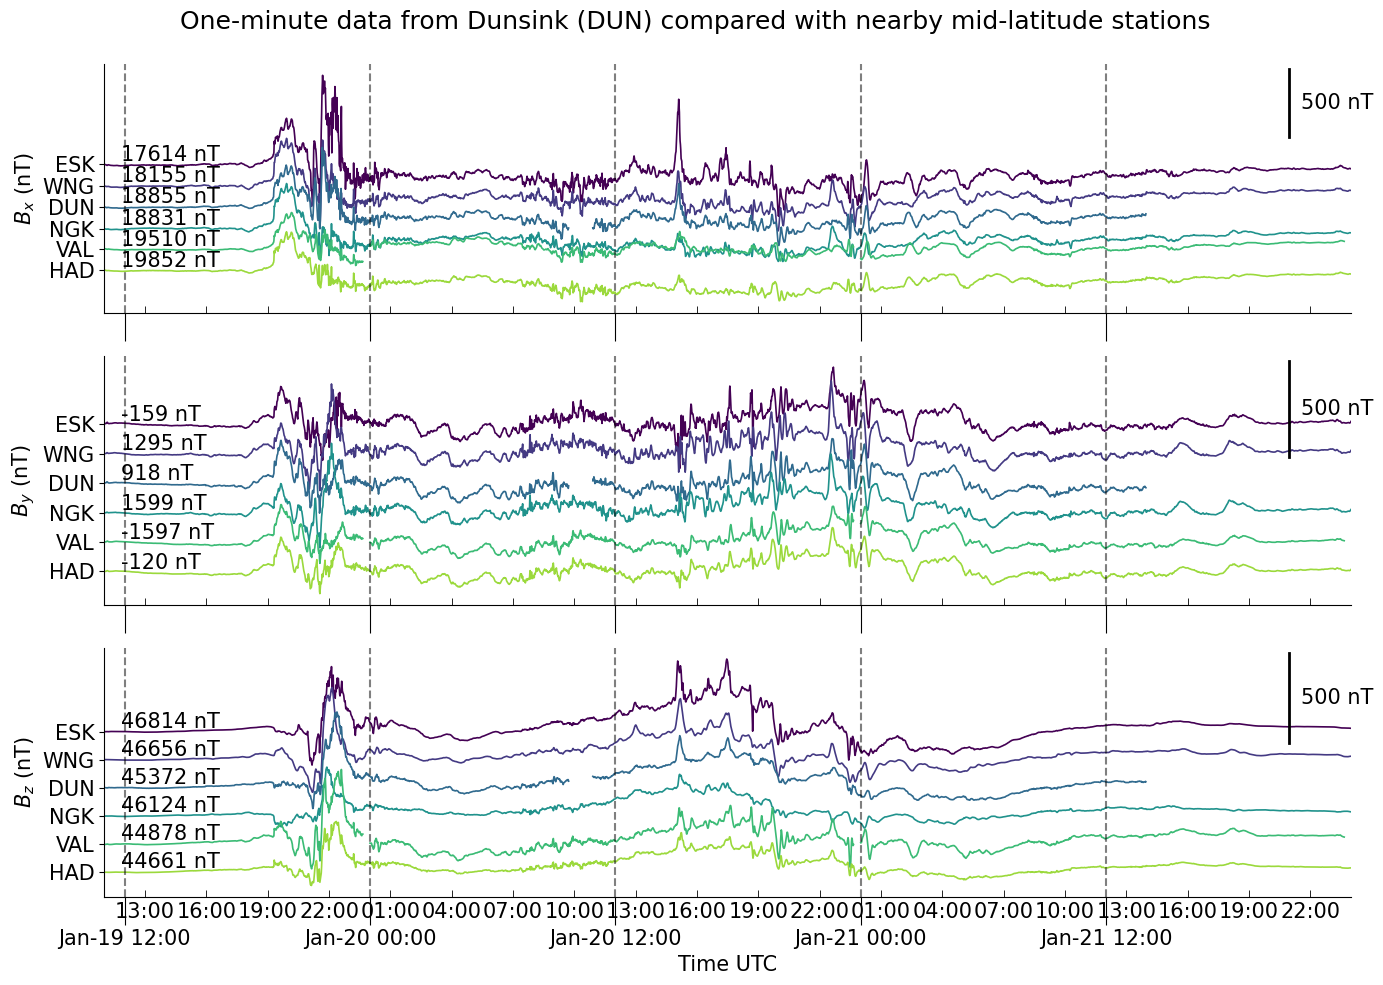

In [12]:
padding_fraction = 0.15
component_list = ['X', 'Y', 'Z']
scale_len_dict = {"X": (500, "nT"), "Y": (500, "nT"), "Z": (500, "nT")}
y_labels = ["$B_x$ (nT)", "$B_y$ (nT)", "$B_z$ (nT)"]
title = 'One-minute data from Dunsink (DUN) compared with \
nearby mid-latitude stations'
file_name = 'Mid-Latitude_Jan19-21_Bxyz.png'
fig, ax, y_offsets_per_obs = stack_plot(
        df_minute_obs, obs_plot_list, padding_fraction, component_list,
        means, scale_len_dict, y_labels, title, file_name, output_file_path,
        print_msg=True
        )
plt.show()

Plot the dB/dt by minute of up to four components.

Using vertical spacing of 2 nT
Plot Minute_derviatives_Mid-Latitude_Jan19-21_HXYZ.png is saved in ../Data


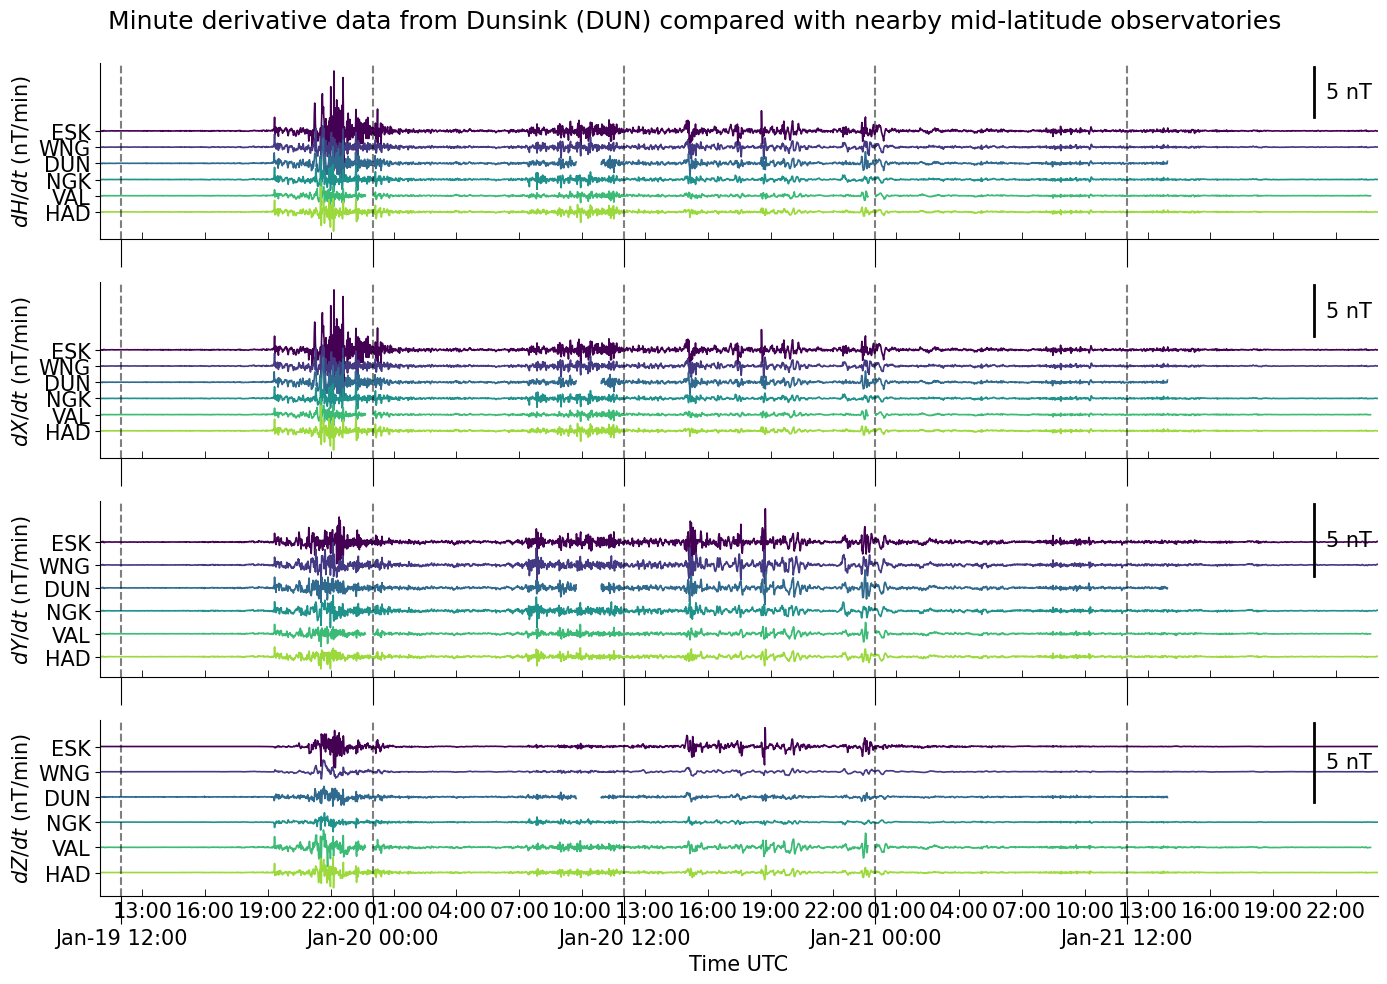

In [17]:
component_list = ['dHdt', 'dXdt', 'dYdt', 'dZdt']
scale_len_dict = {"dHdt": (5, "nT"), "dXdt": (5, "nT"), "dYdt": (5, "nT"), "dZdt": (5, "nT")}
y_labels = ["$dH/dt$ (nT/min)", "$dX/dt$ (nT/min)", "$dY/dt$ (nT/min)", "$dZ/dt$ (nT/min)"]
title = 'Minute derivative data from Dunsink (DUN) compared with \
nearby mid-latitude observatories'
file_name = 'Minute_derviatives_Mid-Latitude_Jan19-21_HXYZ.png'

fig, ax, y_offsets_per_obs_deriv = stack_plot(
        df_minute_obs, obs_plot_list, padding_fraction, component_list,
        means, scale_len_dict, y_labels, title, file_name, output_file_path,
        print_msg=True
        )
plt.show()

In [18]:
df_minute_obs

,ESKX,ESKY,ESKZ,ESKH,ESKdXdt,ESKdYdt,ESKdZdt,ESKdHdt,WNGX,WNGY,...,VALdZdt,VALdHdt,HADX,HADY,HADZ,HADH,HADdXdt,HADdYdt,HADdZdt,HADdHdt
2026-01-19 11:00:00,17619.73,-153.56,46812.6,17620.399143,NaN,NaN,NaN,NaN,18156.63,1299.55,...,NaN,NaN,19857.99,-111.49,44659.0,19858.302970,NaN,NaN,NaN,NaN
2026-01-19 11:01:00,17619.23,-154.02,46812.7,17619.903177,-0.008333,-0.007667,0.001667,-0.008266,18156.00,1299.32,...,-0.008000,-0.002632,19857.48,-111.95,44658.6,19857.795566,-0.008500,-0.007667,-0.006667,-0.008457
2026-01-19 11:02:00,17618.03,-153.85,46812.8,17618.701737,-0.020000,0.002833,0.001667,-0.020024,18155.21,1299.59,...,-0.005333,-0.007415,19856.68,-112.17,44658.4,19856.996821,-0.013333,-0.003667,-0.003333,-0.013312
2026-01-19 11:03:00,17617.53,-153.64,46812.9,17618.199924,-0.008333,0.003500,0.001667,-0.008364,18155.10,1299.61,...,-0.001167,-0.004234,19856.58,-112.17,44658.4,19856.896822,-0.001667,0.000000,0.000000,-0.001667
2026-01-19 11:04:00,17616.74,-152.61,46812.9,17617.401001,-0.013167,0.017167,0.000000,-0.013315,18154.54,1300.10,...,0.003833,-0.010626,19856.09,-111.65,44658.4,19856.403899,-0.008167,0.008667,0.000000,-0.008215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-21 23:55:00,17590.36,-150.54,46831.8,17591.004156,0.001667,-0.001667,-0.005000,0.001681,18125.37,1306.42,...,NaN,NaN,19830.50,-108.28,44681.8,19830.795617,0.006667,-0.000167,0.001667,0.006667
2026-01-21 23:56:00,17589.86,-149.82,46831.5,17590.498027,-0.008333,0.012000,-0.005000,-0.008435,18125.16,1307.69,...,NaN,NaN,19830.41,-107.64,44681.7,19830.702134,-0.001500,0.010667,-0.001667,-0.001558
2026-01-21 23:57:00,17588.38,-148.07,46831.4,17589.003262,-0.024667,0.029167,-0.001667,-0.024913,18124.44,1309.78,...,NaN,NaN,19829.61,-106.54,44681.7,19829.896206,-0.013333,0.018333,0.000000,-0.013432
2026-01-21 23:58:00,17587.30,-144.89,46831.5,17587.896816,-0.018000,0.053000,0.001667,-0.018441,18124.35,1313.00,...,NaN,NaN,19828.93,-104.23,44682.1,19829.203939,-0.011333,0.038500,0.006667,-0.011538
